# AI药物设计 - 第5课：神经网络基础

## 学习目标
1. 理解激活函数的作用（Sigmoid和ReLU）
2. 掌握神经网络的前向传播
3. 手动实现神经网络训练（巩固反向传播）
4. 使用PyTorch简化神经网络实现

## 1. 导入必要的库

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

## 2. 激活函数

### 为什么需要激活函数？
- 线性回归只能拟合直线
- 激活函数引入非线性，让神经网络能拟合复杂曲线

In [2]:
def sigmoid(z):
    """Sigmoid: σ(z) = 1 / (1 + e^(-z))"""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """Sigmoid导数: σ'(z) = σ(z) × (1 - σ(z))"""
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """ReLU: max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """ReLU导数: z>0时为1，否则为0"""
    return (z > 0).astype(float)

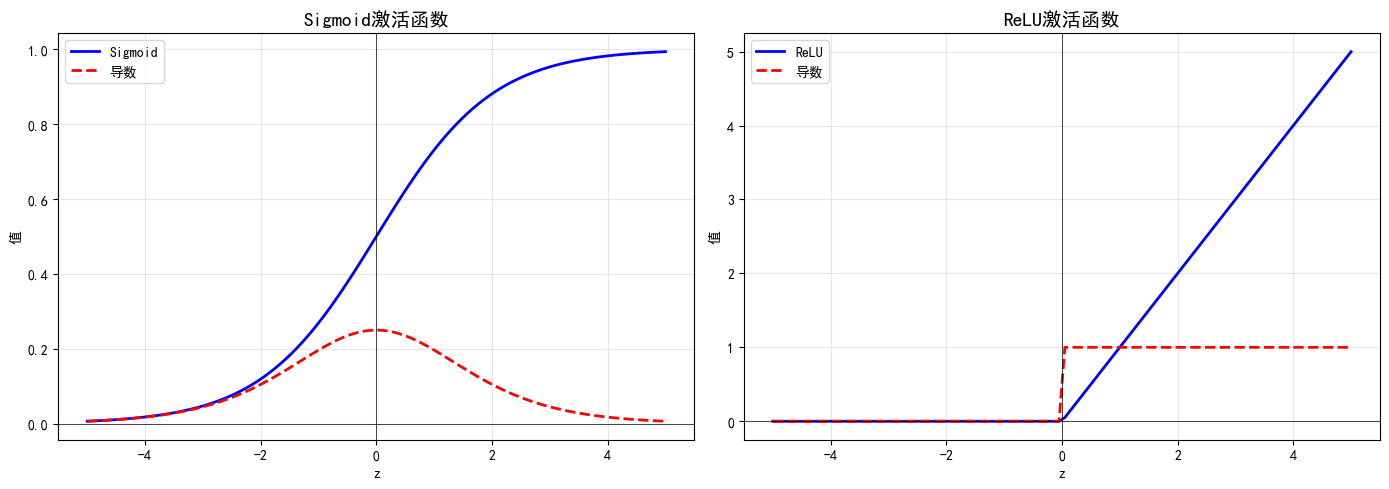

In [3]:
# 可视化激活函数
z = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid
axes[0].plot(z, sigmoid(z), 'b-', linewidth=2, label='Sigmoid')
axes[0].plot(z, sigmoid_derivative(z), 'r--', linewidth=2, label='导数')
axes[0].set_title('Sigmoid激活函数', fontsize=14)
axes[0].set_xlabel('z')
axes[0].set_ylabel('值')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

# ReLU
axes[1].plot(z, relu(z), 'b-', linewidth=2, label='ReLU')
axes[1].plot(z, relu_derivative(z), 'r--', linewidth=2, label='导数')
axes[1].set_title('ReLU激活函数', fontsize=14)
axes[1].set_xlabel('z')
axes[1].set_ylabel('值')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

## 3. 单个神经元

### 神经元 = 线性变换 + 激活函数
- **线性变换**: z = w·x + b
- **激活函数**: a = σ(z)

In [4]:
# 示例：药物分子特征
x = np.array([180, 2.0, 3])  # [分子量, LogP, 氢键供体数]
w = np.array([-0.01, 0.5, -0.2])
b = 2.0

# 神经元计算
z = np.dot(w, x) + b
a = sigmoid(z)

print(f"输入特征: {x}")
print(f"线性组合: z = {z:.3f}")
print(f"激活输出: a = {a:.3f}")
print(f"\n解释: 该分子有 {a*100:.1f}% 的可能性具有活性")

输入特征: [180.   2.   3.]
线性组合: z = 0.600
激活输出: a = 0.646

解释: 该分子有 64.6% 的可能性具有活性


## 4. 多层神经网络

### 网络结构
```
输入层(n个特征) → 隐藏层(m个神经元) → 输出层(1个神经元)
```

In [5]:
def forward_pass(X, W1, b1, W2, b2):
    """
    两层神经网络前向传播
    X: 输入 (n_samples, n_features)
    返回: 预测值 和 中间结果cache
    """
    # 第一层: 输入 → 隐藏
    Z1 = X @ W1.T + b1  # (n, m)
    A1 = relu(Z1)        # ReLU激活
    
    # 第二层: 隐藏 → 输出
    Z2 = A1 @ W2.T + b2  # (n, 1)
    A2 = sigmoid(Z2)     # Sigmoid激活
    
    cache = {'X': X, 'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

In [6]:
# 测试前向传播
X_test = np.array([[1.0, 2.0]])  # 1个样本, 2个特征
W1 = np.array([[0.5, -0.3], [0.2, 0.4]])  # (2, 2)
b1 = np.array([0.1, -0.2])
W2 = np.array([[0.6, -0.4]])  # (1, 2)
b2 = np.array([0.3])

y_pred, cache = forward_pass(X_test, W1, b1, W2, b2)

print("=== 前向传播演示 ===")
print(f"输入: {X_test[0]}")
print(f"隐藏层输出: {cache['A1'][0]}")
print(f"最终输出: {y_pred[0, 0]:.3f}")

=== 前向传播演示 ===
输入: [1. 2.]
隐藏层输出: [2.77555756e-17 8.00000000e-01]
最终输出: 0.495


## 5. 手动训练神经网络

### 训练步骤（和线性回归一样的四步）
1. 前向传播
2. 损失计算
3. 梯度计算（反向传播）
4. 参数更新

In [7]:
def compute_gradients(cache, y_true, W2):
    """
    计算梯度（反向传播）
    """
    n = len(y_true)
    X = cache['X']
    A1 = cache['A1']
    A2 = cache['A2']
    Z1 = cache['Z1']
    
    # 输出层梯度
    dZ2 = A2 - y_true.reshape(-1, 1)  # (n, 1)
    dW2 = (1/n) * dZ2.T @ A1           # (1, m)
    db2 = (1/n) * np.sum(dZ2, axis=0)  # (1,)
    
    # 隐藏层梯度
    dA1 = dZ2 @ W2                     # (n, m)
    dZ1 = dA1 * relu_derivative(Z1)    # (n, m)
    dW1 = (1/n) * dZ1.T @ X            # (m, features)
    db1 = (1/n) * np.sum(dZ1, axis=0)  # (m,)
    
    return dW1, db1, dW2, db2

In [8]:
# 准备数据：剂量-效应关系（非线性）
np.random.seed(42)
doses = np.linspace(0, 10, 60).reshape(-1, 1)
true_effect = sigmoid(1.2 * (doses - 5))
noise = np.random.normal(0, 0.05, size=true_effect.shape)
observed_effect = np.clip(true_effect + noise, 0, 1)

# 特征归一化
X = doses / 10
y = observed_effect.flatten()

print(f"数据集: {len(X)} 个样本")
print(f"输入范围: [{X.min():.2f}, {X.max():.2f}]")
print(f"输出范围: [{y.min():.2f}, {y.max():.2f}]")

数据集: 60 个样本
输入范围: [0.00, 1.00]
输出范围: [0.00, 1.00]


In [9]:
# 初始化参数
np.random.seed(0)
hidden_size = 8
W1 = np.random.randn(hidden_size, 1) * 0.3
b1 = np.zeros(hidden_size)
W2 = np.random.randn(1, hidden_size) * 0.3
b2 = np.zeros(1)

# 训练参数
learning_rate = 0.1
epochs = 2000
losses = []

print("=== 开始训练 ===")
print(f"隐藏层大小: {hidden_size}")
print(f"学习率: {learning_rate}")
print(f"训练轮数: {epochs}")
print("=" * 50)

for epoch in range(epochs):
    # 1. 前向传播
    y_pred, cache = forward_pass(X, W1, b1, W2, b2)
    
    # 2. 损失计算
    loss = np.mean((y_pred.flatten() - y) ** 2)
    losses.append(loss)
    
    # 3. 梯度计算
    dW1, db1, dW2, db2 = compute_gradients(cache, y, W2)
    
    # 4. 参数更新
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss:.6f}")

print("=" * 50)
print("训练完成！")

=== 开始训练 ===
隐藏层大小: 8
学习率: 0.1
训练轮数: 2000
Epoch  500 | Loss: 0.005124
Epoch 1000 | Loss: 0.001893
Epoch 1500 | Loss: 0.001627
Epoch 2000 | Loss: 0.001585
训练完成！


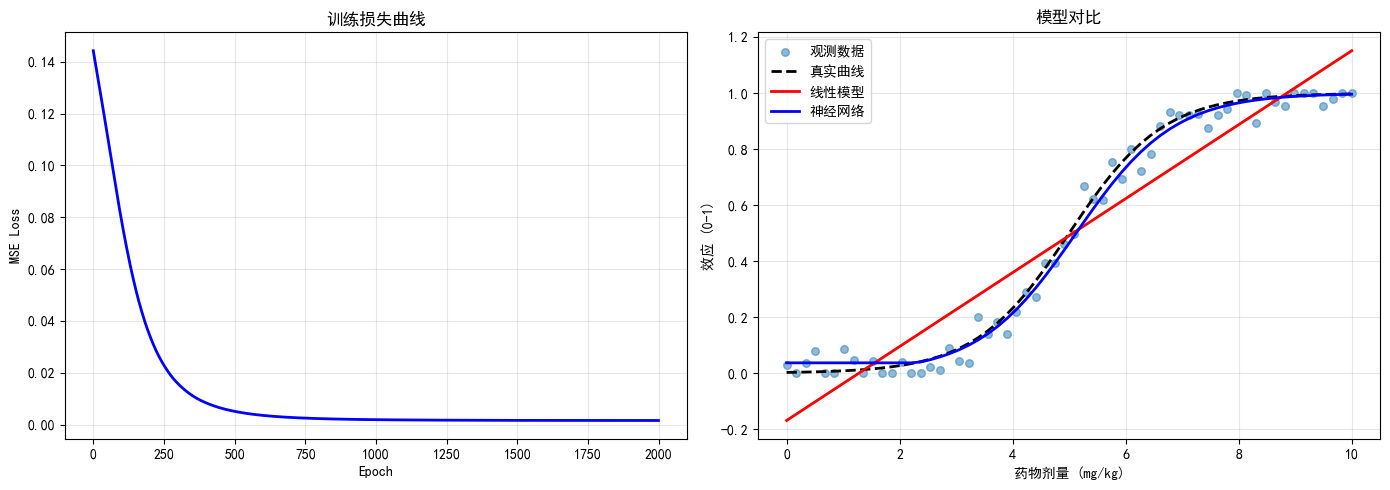


线性模型 MSE: 0.012132
神经网络 MSE: 0.000466


In [10]:
# 可视化结果
y_pred_final, _ = forward_pass(X, W1, b1, W2, b2)

# 对比线性模型
linear_coef = np.polyfit(doses.flatten(), y, 1)
linear_pred = np.polyval(linear_coef, doses.flatten())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：损失曲线
axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('训练损失曲线')
axes[0].grid(True, alpha=0.3)

# 右图：拟合效果
axes[1].scatter(doses, y, alpha=0.5, s=30, label='观测数据')
axes[1].plot(doses, true_effect, 'k--', linewidth=2, label='真实曲线')
axes[1].plot(doses, linear_pred, 'r-', linewidth=2, label='线性模型')
axes[1].plot(doses, y_pred_final, 'b-', linewidth=2, label='神经网络')
axes[1].set_xlabel('药物剂量 (mg/kg)')
axes[1].set_ylabel('效应 (0-1)')
axes[1].set_title('模型对比')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n线性模型 MSE: {np.mean((linear_pred - true_effect.flatten())**2):.6f}")
print(f"神经网络 MSE: {np.mean((y_pred_final.flatten() - true_effect.flatten())**2):.6f}")

## 6. PyTorch实现神经网络

### 优势
- **自动求导**：不需要手动计算梯度
- **GPU加速**：支持大规模训练
- **模块化**：代码更简洁

In [11]:
# 定义神经网络
class DrugNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1):
        super(DrugNet, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h = torch.relu(self.layer1(x))      # 隐藏层 + ReLU
        y = torch.sigmoid(self.layer2(h))   # 输出层 + Sigmoid
        return y

# 创建模型
model = DrugNet(input_size=1, hidden_size=8)

print("神经网络结构:")
print(model)
print(f"\n总参数数: {sum(p.numel() for p in model.parameters())}")

神经网络结构:
DrugNet(
  (layer1): Linear(in_features=1, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)

总参数数: 25


In [12]:
# 准备PyTorch数据
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 训练循环
print("=== PyTorch训练 ===")
model.train()
torch_losses = []

for epoch in range(2000):
    # 前向传播
    y_pred = model(X_tensor)
    
    # 损失计算
    loss = criterion(y_pred, y_tensor)
    torch_losses.append(loss.item())
    
    # 反向传播 + 参数更新（PyTorch自动完成！）
    optimizer.zero_grad()  # 清空梯度
    loss.backward()        # 自动计算梯度
    optimizer.step()       # 更新参数
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss.item():.6f}")

print("\n训练完成！")

=== PyTorch训练 ===
Epoch  500 | Loss: 0.001506
Epoch 1000 | Loss: 0.001499
Epoch 1500 | Loss: 0.001497
Epoch 2000 | Loss: 0.001495

训练完成！


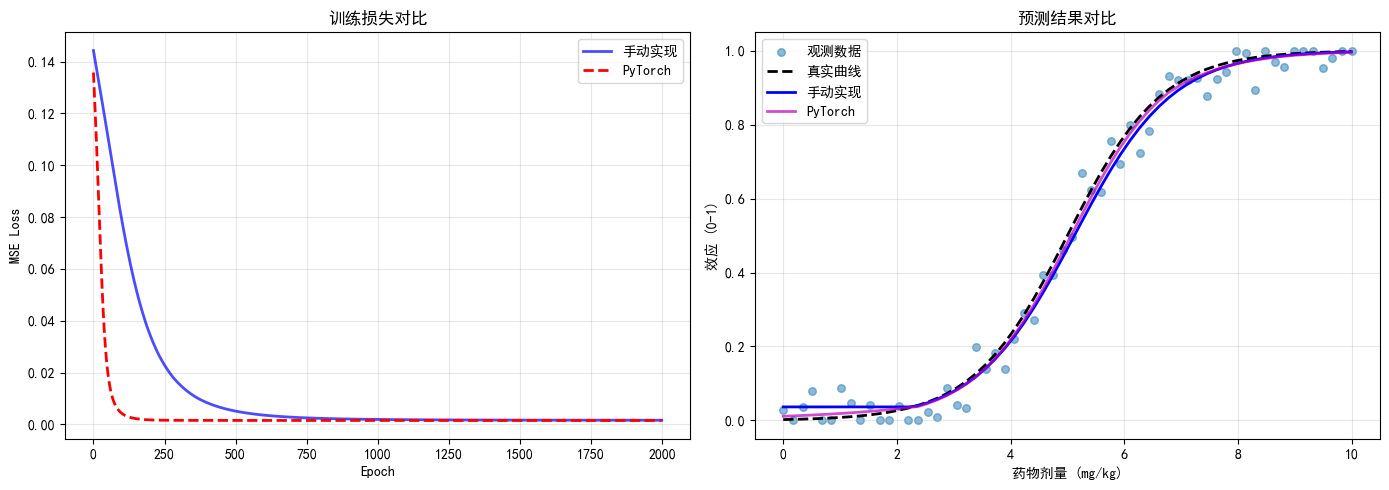


手动实现 MSE: 0.000466
PyTorch MSE:  0.000118

新剂量预测 (7 mg/kg): 0.908 (效应90.8%)


In [13]:
# 评估模型
model.eval()
with torch.no_grad():
    y_pred_torch = model(X_tensor).numpy()
    
    # 预测新样本
    new_dose = torch.tensor([[0.7]], dtype=torch.float32)  # 7 mg/kg
    new_pred = model(new_dose).item()

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：损失对比
axes[0].plot(losses, 'b-', linewidth=2, label='手动实现', alpha=0.7)
axes[0].plot(torch_losses, 'r--', linewidth=2, label='PyTorch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('训练损失对比')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：预测对比
axes[1].scatter(doses, y, alpha=0.5, s=30, label='观测数据')
axes[1].plot(doses, true_effect, 'k--', linewidth=2, label='真实曲线')
axes[1].plot(doses, y_pred_final, 'b-', linewidth=2, label='手动实现')
axes[1].plot(doses, y_pred_torch, 'm-', linewidth=2, label='PyTorch', alpha=0.7)
axes[1].set_xlabel('药物剂量 (mg/kg)')
axes[1].set_ylabel('效应 (0-1)')
axes[1].set_title('预测结果对比')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n手动实现 MSE: {np.mean((y_pred_final.flatten() - true_effect.flatten())**2):.6f}")
print(f"PyTorch MSE:  {np.mean((y_pred_torch.flatten() - true_effect.flatten())**2):.6f}")
print(f"\n新剂量预测 (7 mg/kg): {new_pred:.3f} (效应{new_pred*100:.1f}%)")

## 7. 总结

### 核心概念
1. **激活函数**：引入非线性，使网络能拟合复杂曲线
   - Sigmoid: 用于输出层（二分类）
   - ReLU: 用于隐藏层（训练快、效果好）

2. **神经网络训练**：和线性回归一样的四步
   - 前向传播 → 损失计算 → 梯度计算 → 参数更新

3. **手动实现 vs PyTorch**
   - 手动实现：理解原理
   - PyTorch：自动求导，代码简洁

### 关键代码对比

**手动实现**（需要手写梯度）：
```python
for epoch in range(epochs):
    y_pred, cache = forward_pass(X, W1, b1, W2, b2)
    loss = mse_loss(y_pred, y)
    dW1, db1, dW2, db2 = compute_gradients(cache, y, W2)  # 手动计算梯度
    W1 -= lr * dW1
    W2 -= lr * dW2
```

**PyTorch**（自动求导）：
```python
for epoch in range(epochs):
    y_pred = model(X)
    loss = criterion(y_pred, y)
    optimizer.zero_grad()
    loss.backward()      # 自动计算梯度！
    optimizer.step()
```

## 8. 课后练习

1. 修改隐藏层大小，观察对训练的影响
2. 尝试不同的学习率
3. 将ReLU改成其他激活函数（如tanh）
4. 添加更多隐藏层，构建更深的网络